In [14]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input


In [15]:
# Load Training Dataset
df_train = pd.read_csv("/content/Google_Stock_Price_Train.csv")

# Display dataset
df_train.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [16]:

# Extract Open Price Column
training_set = df_train.iloc[:, 1:2].values

print("Training Set Shape:", training_set.shape)


Training Set Shape: (1258, 1)


In [17]:

# Feature Scaling
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)


In [18]:

# Create Data Structure with 60 Timesteps
X_train = []
y_train = []

for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train Shape Before Reshape:", X_train.shape)
print("y_train Shape:", y_train.shape)


X_train Shape Before Reshape: (1198, 60)
y_train Shape: (1198,)


In [19]:

# Reshape for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

print("X_train Shape After Reshape:", X_train.shape)


X_train Shape After Reshape: (1198, 60, 1)


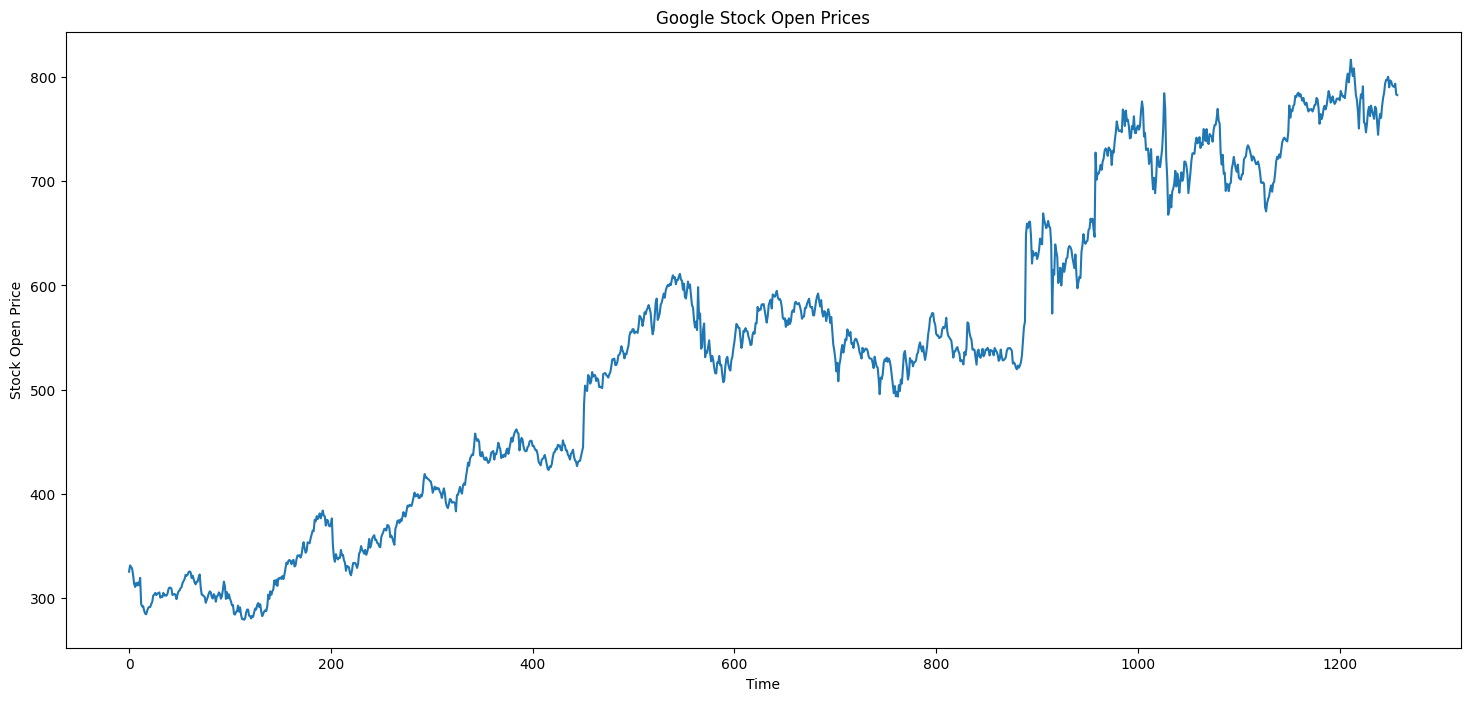

In [20]:

# Visualize Open Prices
plt.figure(figsize=(18,8))
plt.plot(df_train['Open'])
plt.title("Google Stock Open Prices")
plt.xlabel("Time")
plt.ylabel("Stock Open Price")
plt.show()


In [21]:

# Build LSTM Model
regressor = Sequential()

# First LSTM Layer
regressor.add(Input(shape=(X_train.shape[1], 1)))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Second LSTM Layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Third LSTM Layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Fourth LSTM Layer
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Output Layer
regressor.add(Dense(units=1))

# Compile Model
regressor.compile(optimizer='adam', loss='mean_squared_error')

# Model Summary
regressor.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:

# Train Model
history = regressor.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)


Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - loss: 0.0456
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0076
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - loss: 0.0053
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 0.0053
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - loss: 0.0050
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0045
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - loss: 0.0052
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0046
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0041
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - loss: 0.0043
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0043
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0043
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - loss: 0.0040
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0037
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - l

In [24]:

# Load Test Dataset
df_test = pd.read_csv("Google_Stock_Price_Train.csv")

df_test.head()


,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [25]:

# Real Stock Prices
real_stock_price = df_test.iloc[:, 1:2].values


In [26]:

# Combine Train and Test Open Prices
dataset_total = pd.concat(
    (df_train['Open'], df_test['Open']),
    axis=0
)

inputs = dataset_total[len(dataset_total) - len(df_test) - 60:].values
inputs = inputs.reshape(-1, 1)

# Scale Inputs
inputs = sc.transform(inputs)


In [27]:

# Prepare Test Data
X_test = []

for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)

# Reshape
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print("X_test Shape:", X_test.shape)


X_test Shape: (1258, 60, 1)


In [28]:

# Predict Stock Prices
predicted_stock_price = regressor.predict(X_test)

# Inverse Scaling
predicted_stock_price = sc.inverse_transform(predicted_stock_price)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step


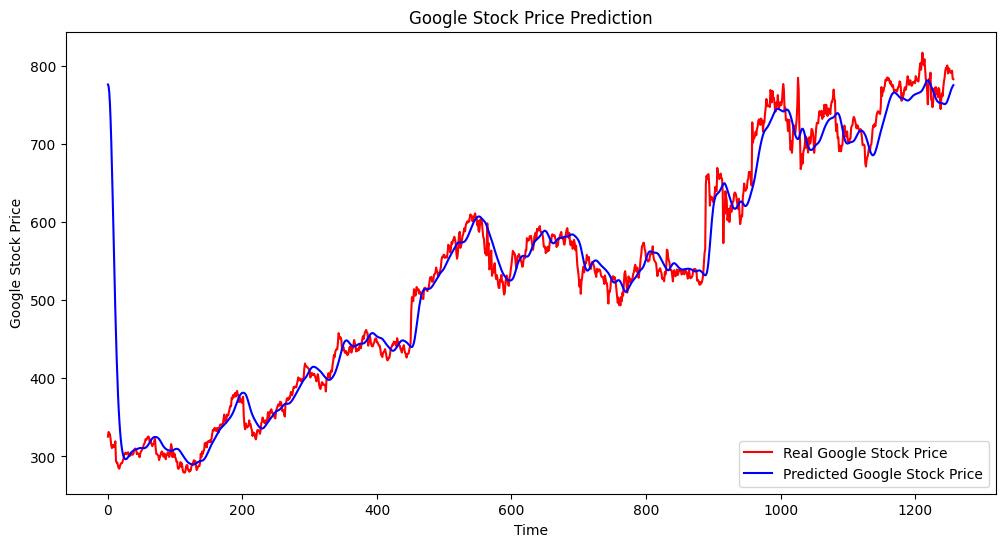

In [29]:

# Visualize Results
plt.figure(figsize=(12,6))

plt.plot(real_stock_price, color='red', label='Real Google Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')

plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()

plt.show()
